In [4]:
import numpy as np
import matplotlib.pyplot as plt

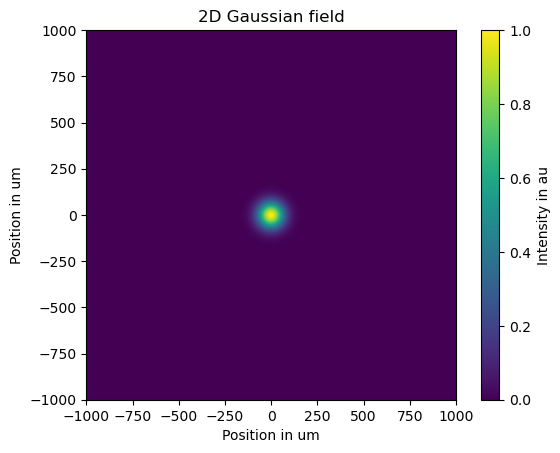

In [5]:
dx_m = 1e-6 #grid size, m:meter
Dx_m = 2e-3 #screen size
x_m = np.linspace(-Dx_m/2, Dx_m/2, int(Dx_m/dx_m)+1) #spatial grid along x-axis 

x_mean_m = 0.0 #centered on...
x_std_m = 50e-6 #widthofgaussian



dy_m = 1e-6 #grid size, m:meter
Dy_m = Dx_m
y_m = np.linspace(-Dy_m/2, Dy_m/2, int(Dy_m/dy_m)+1) #spatial grid along y-axis 



X, Y = np.meshgrid(x_m, y_m) #2D grid
uin_V_m = np.exp(-(X**2 + Y**2)/(2*(x_std_m**2))) #2D Gaussian field
plt.imshow(uin_V_m, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("2D Gaussian field")
plt.colorbar(label="Intensity in au")
plt.show()

In [6]:
def ft(t):
    return np.fft.fftshift( np.fft.fft2(np.fft.ifftshift(t)))

def ift(t):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(t)))

def fs(t):
    # works with Matlab, breaks with python
    #return (np.arange(0,1/(t[1]-t[0]),1/((t[1]-t[0])*len(t)))) - (1/(t[1]-t[0])-np.mod(len(t),2)*1/((t[1]-t[0])*len(t)))/2
    
    # from https://stackoverflow.com/questions/3694918/how-to-extract-frequency-associated-with-fft-values-in-python
    N = len(t)
    df_cpm = 1/(t[-1]-t[0])
    f_cpm = np.fft.fftshift(np.array([df_cpm*n if n<N/2 else df_cpm*(n-N) for n in range(N)]))
    return f_cpm

def propTF(E_in,L_m,lambda_m,z_m):
    #get input field array size
    (Nx, Ny)=np.shape(E_in); 
    dx=L_m/Nx; #sample interval

    #(dx<lambda.*z/L)


    fx = fs(np.arange(Nx)*dx);
    if Ny>2:
        fy = fs(np.arange(Ny)*dx);
    else:
        fy = 0;

    [FX,FY]= np.meshgrid(fx,fy);

    H=np.exp(-1j*np.pi*lambda_m*z_m*(FX**2+FY**2))

    E_out = ft(ft(E_in)*H);
    
    return E_out


In [7]:
def propTF2(uin_V_m, Lx_m, Ly_m, lambda_m, z_m):
    """
    2D transfer-function Fresnel propagation.
    uin_V_m: 2D input field (Ny, Nx)
    Lx_m, Ly_m: physical sizes of the window in x and y (meters)
    lambda_m: wavelength (meters)
    z_m: propagation distance (meters)
    """
    Ny, Nx = uin_V_m.shape
    dx = Lx_m / Nx
    dy = Ly_m / Ny

    # frequency coordinates (cycles per meter), centered
    fx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
    fy = np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))
    FX, FY = np.meshgrid(fx, fy)

    # 2D transfer function for Fresnel propagation
    H = np.exp(-1j * np.pi * lambda_m * z_m * (FX**2 + FY**2))

    # Forward 2D FFT (shift input to center first)
    Uin = np.fft.fft2(np.fft.fftshift(uin_V_m))

    # Multiply in frequency domain and inverse FFT (then unshift)
    Uout = H * Uin
    uout = np.fft.ifftshift(np.fft.ifft2(Uout))

    return uout

In [8]:
E_source = uin_V_m
E_image = E_source

#propagate E_source, back propagate E_image, 

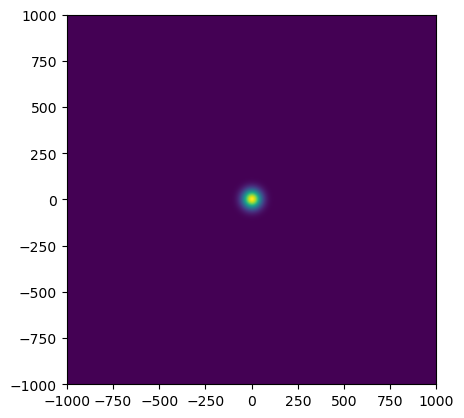

In [9]:
plt.imshow(np.abs(E_source)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.show()


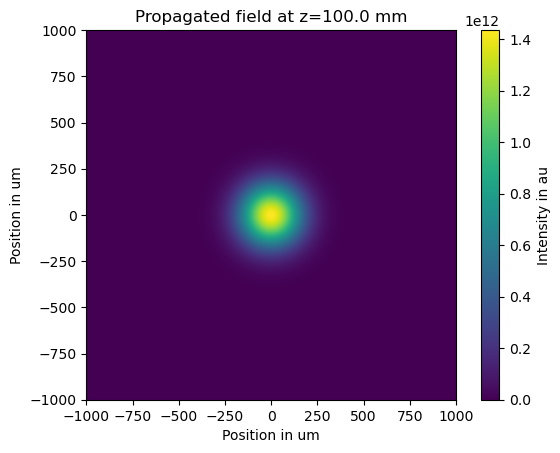

In [10]:
z_prop_m = 0.1
E_source_prop = propTF(E_source, Dx_m, 500e-9, z_prop_m)
plt.imshow(np.abs(E_source_prop)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title(f"Propagated field at z={z_prop_m*1e3:.1f} mm")
plt.colorbar(label="Intensity in au")
plt.show()

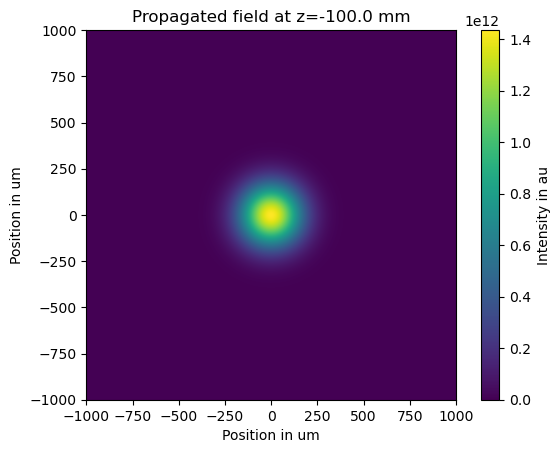

In [11]:
z_prop_m = -0.1
E_image_prop = propTF(E_image, Dx_m, 500e-9, z_prop_m)
plt.imshow(np.abs(E_image_prop)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title(f"Propagated field at z={z_prop_m*1e3:.1f} mm")
plt.colorbar(label="Intensity in au")
plt.show()

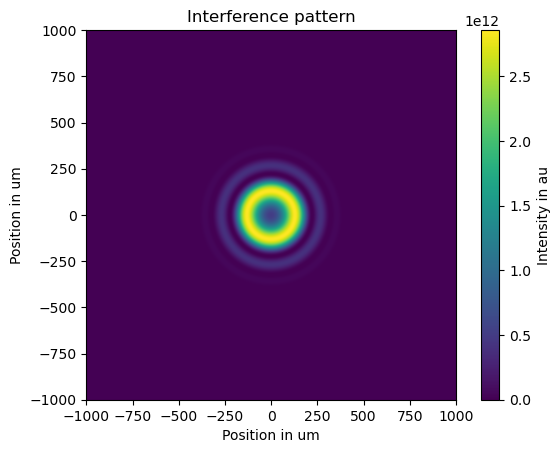

In [12]:
I_sum = np.abs(E_source_prop + E_image_prop)**2
plt.imshow(I_sum, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Interference pattern")
plt.colorbar(label="Intensity in au")
plt.show()


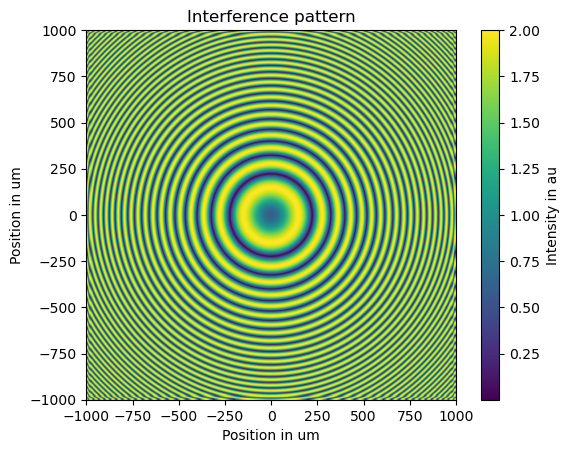

In [13]:
I_sum2 = np.abs(np.exp(1j*np.angle(E_source_prop)) + np.exp(1j*np.angle(E_image_prop)))
# with np.angle, discarding intensity, only care about phase interference pattern
plt.imshow(I_sum2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Interference pattern")
plt.colorbar(label="Intensity in au")
plt.show()

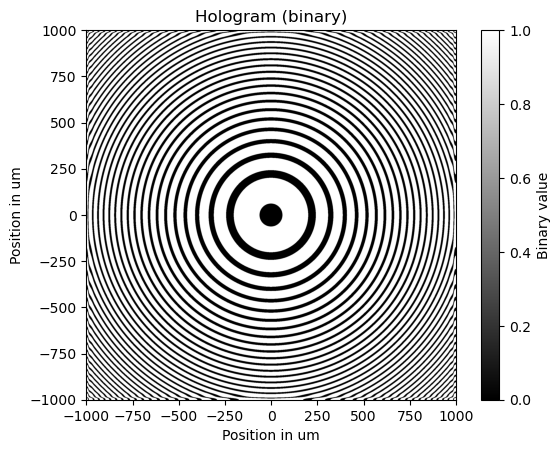

In [14]:
hologram = (I_sum2/2) >= 0.5 #0.5 is threshold
plt.imshow(hologram, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower', cmap='gray')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Hologram (binary)")
plt.colorbar(label="Binary value")
plt.show()

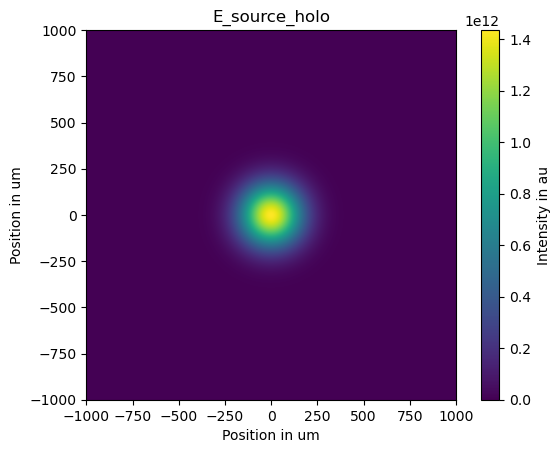

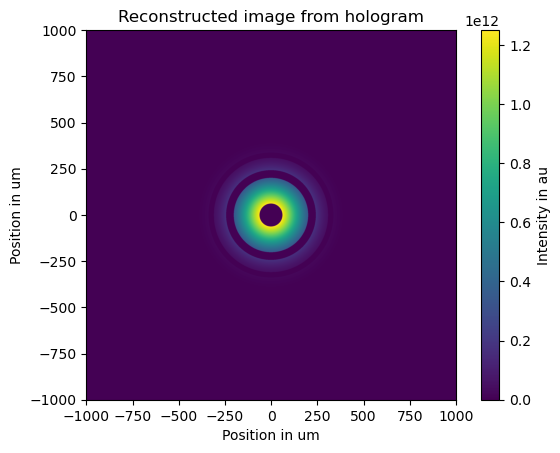

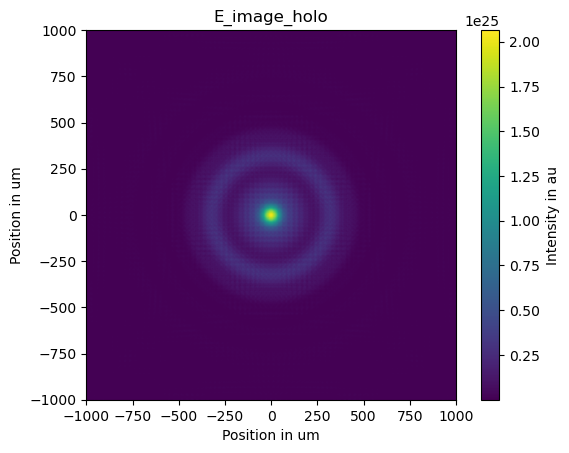

In [15]:
E_source_holo = propTF(E_source, Dx_m, 500e-9, z_prop_m)
E_holo = E_source_holo * hologram
E_image_holo = propTF(E_holo, Dx_m, 500e-9, z_prop_m)


plt.imshow(np.abs(E_source_holo)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("E_source_holo")
plt.colorbar(label="Intensity in au")
plt.show()


plt.imshow(np.abs(E_holo)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Reconstructed image from hologram")
plt.colorbar(label="Intensity in au")
plt.show()

plt.imshow(np.abs(E_image_holo)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")      
plt.title("E_image_holo")
plt.colorbar(label="Intensity in au")
plt.show()


In [16]:
#try changing back propagating distance of img
#try to make holo where img beam is spiral beam & see if get a spiral beam back
#try to see if forward & back prop distances are diff 
#copy and run "supreme" repo, will use for speckle simulations (chat) 

#hologram IS zone plate 
#can import any profile we want, ex: if image is not spiral beam, can be pi/2 phase step, can add aberrations (if image has additional phase), etc.
#can add additional phase into hologram

In [17]:
# #try changing back propagating distance of img

# z_prop_m = 0.1
# E_source_prop = propTF(E_source, Dx_m, 500e-9, z_prop_m)
# plt.imshow(np.abs(E_source_prop)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title(f"Propagated field at z={z_prop_m*1e3:.1f} mm")
# plt.colorbar(label="Intensity in au")
# plt.show()

# #---------------------------

# z_prop2_m = -0.3
# E_image2_prop = propTF(E_image, Dx_m, 500e-9, z_prop2_m)
# plt.imshow(np.abs(E_image2_prop)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title(f"Propagated field at z={z_prop2_m*1e3:.1f} mm")
# plt.colorbar(label="Intensity in au")
# plt.show()

# #---------------------------

# I_sum = np.abs(E_source_prop + E_image2_prop)**2
# plt.imshow(I_sum, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title("Interference pattern")
# plt.colorbar(label="Intensity in au")
# plt.show()

# #---------------------------

# I_sum3 = np.abs(np.exp(1j*np.angle(E_source_prop)) + np.exp(1j*np.angle(E_image2_prop)))
# # with np.angle, discarding intensity, only care about phase interference pattern
# plt.imshow(I_sum3, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title("Interference pattern")
# plt.colorbar(label="Intensity in au")
# plt.show()

# #---------------------------

# hologram = (I_sum3/2) >= 0.5 #0.5 is threshold
# plt.imshow(hologram, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower', cmap='gray')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title("Hologram (binary)")
# plt.colorbar(label="Binary value")
# plt.show()

# #---------------------------

# E_source_holo = propTF(E_source, Dx_m, 500e-9, z_prop_m)
# E_holo = E_source_holo * hologram
# E_image2_holo = propTF(E_holo, Dx_m, 500e-9, z_prop2_m)


# plt.imshow(np.abs(E_source_holo)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title("E_source_holo")
# plt.colorbar(label="Intensity in au")
# plt.show()


# plt.imshow(np.abs(E_holo)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title("Reconstructed image from hologram")
# plt.colorbar(label="Intensity in au")
# plt.show()

# plt.imshow(np.abs(E_image2_holo)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")      
# plt.title("E_image_holo")
# plt.colorbar(label="Intensity in au")
# plt.show()


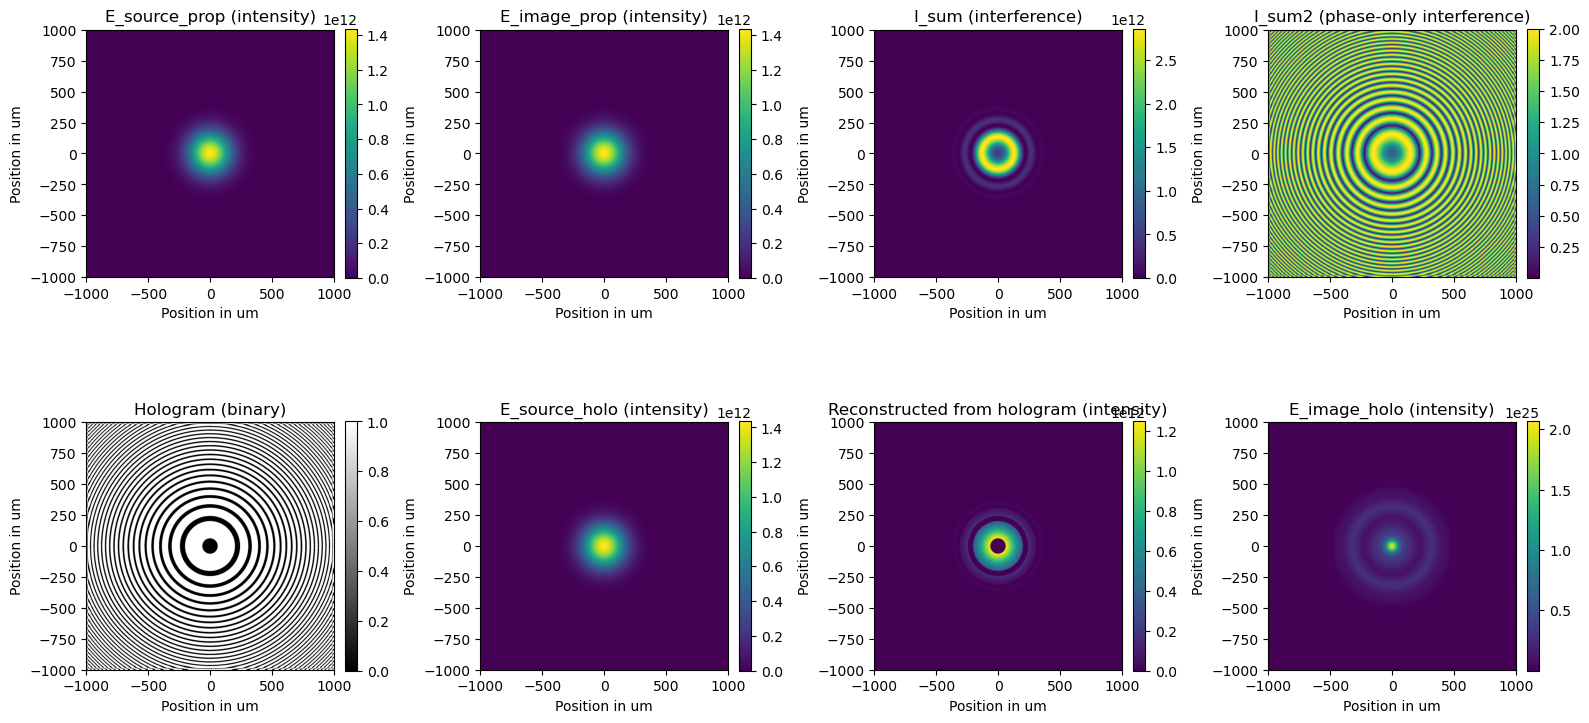

In [21]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.ravel()

# ensure extent and colormap are defined
extent_um = [x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6]
cmap = 'viridis'

data_list = [
    (np.abs(E_source_prop)**2, "E_source_prop (intensity)", cmap),
    (np.abs(E_image_prop)**2, "E_image_prop (intensity)", cmap),
    (I_sum, "I_sum (interference)", cmap),
    (I_sum2, "I_sum2 (phase-only interference)", cmap),
    (hologram.astype(float), "Hologram (binary)", "gray"),
    (np.abs(E_source_holo)**2, "E_source_holo (intensity)", cmap),
    (np.abs(E_holo)**2, "Reconstructed from hologram (intensity)", cmap),
    (np.abs(E_image_holo)**2, "E_image_holo (intensity)", cmap),
]

for ax, (data, title, cm) in zip(axs, data_list):
    im = ax.imshow(data, extent=extent_um, origin='lower', cmap=cm)
    ax.set_title(title)
    ax.set_xlabel("Position in um")
    ax.set_ylabel("Position in um")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


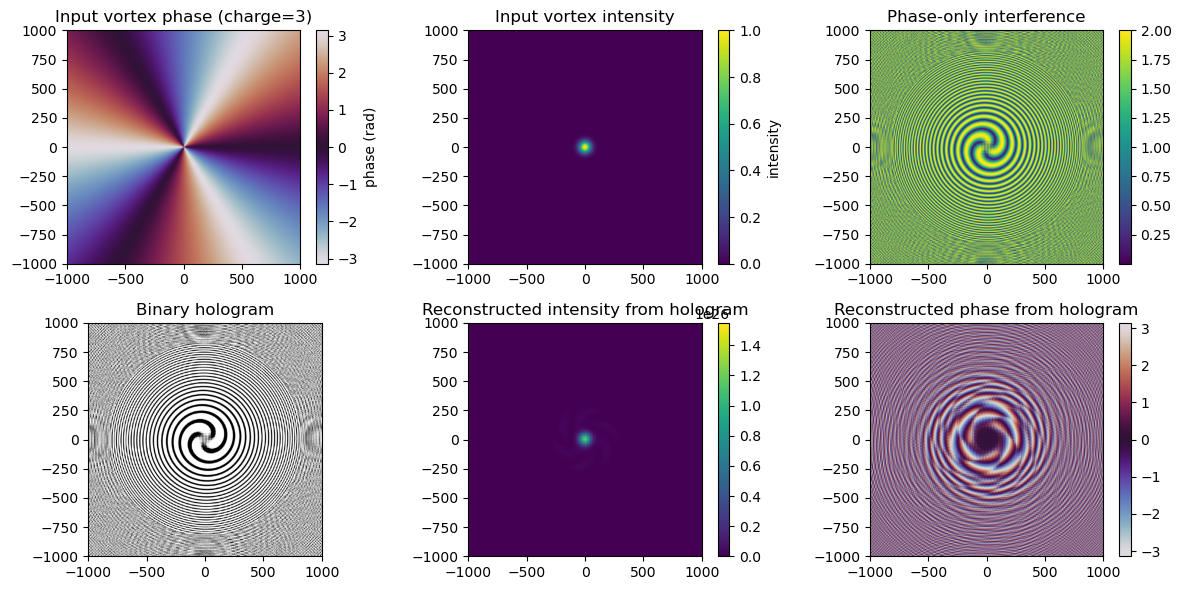

In [24]:
#try to make holo where img beam is spiral beam & see if get a spiral beam back

# generate a spiral (vortex) phase and make the image beam a vortex,
# then create a binary hologram and reconstruct

charge = 3  # topological charge (change to -1, 1, 2, 3, ...)

# reuse X, Y grid already in the notebook
theta = np.arctan2(Y, X)
spiral_phase = np.exp(1j * charge * theta)
vortex = uin_V_m * spiral_phase   # make image beam a vortex

# propagation distances and wavelength
z_src_m = 0.05   # source propagation distance (m)
z_img_m = -0.05  # image (vortex) propagation distance (m)
wavelength = 500e-9

# propagate source and vortex to create interference pattern
E_source_prop = propTF(uin_V_m, Dx_m, wavelength, z_src_m)
E_image_prop  = propTF(vortex, Dx_m, wavelength, z_img_m)

# phase-only interference (make hologram from phase)
I_phase_only = np.abs(np.exp(1j*np.angle(E_source_prop)) + np.exp(1j*np.angle(E_image_prop)))
hologram = (I_phase_only/2) >= 0.5  # binary hologram

# simulate placing hologram on propagated source and reconstructing
E_source_holo = propTF(uin_V_m, Dx_m, wavelength, z_src_m)
E_holo = E_source_holo * hologram
E_image_holo = propTF(E_holo, Dx_m, wavelength, z_img_m)

# quick visual checks
plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(np.angle(vortex), extent=extent_um, origin='lower', cmap='twilight')
plt.title(f"Input vortex phase (charge={charge})")
plt.colorbar(label='phase (rad)')

plt.subplot(2,3,2)
plt.imshow(np.abs(vortex)**2, extent=extent_um, origin='lower')
plt.title("Input vortex intensity")
plt.colorbar(label='intensity')

plt.subplot(2,3,3)
plt.imshow(I_phase_only, extent=extent_um, origin='lower', cmap='viridis')
plt.title("Phase-only interference")
plt.colorbar()

plt.subplot(2,3,4)
plt.imshow(hologram, extent=extent_um, origin='lower', cmap='gray')
plt.title("Binary hologram")

plt.subplot(2,3,5)
plt.imshow(np.abs(E_image_holo)**2, extent=extent_um, origin='lower', cmap='viridis')
plt.title("Reconstructed intensity from hologram")
plt.colorbar()

plt.subplot(2,3,6)
plt.imshow(np.angle(E_image_holo), extent=extent_um, origin='lower', cmap='twilight')
plt.title("Reconstructed phase from hologram")
plt.colorbar()

plt.tight_layout()
plt.show()